# Marketing A/B Test Analysis
## Did the Ad Campaign Work — and How Much Was It Worth?

---

### Business Context

A marketing company ran an A/B test to evaluate the effectiveness 
of an ad campaign. Users were randomly assigned to one of two groups:

- **Ad group (experimental):** Saw the actual product advertisement
- **PSA group (control):** Saw a neutral Public Service Announcement 
  in the exact same ad slot

The PSA group acts as a clean baseline — it isolates the effect of 
the ad by ensuring both groups had the same experience except for 
the ad content itself.

---

### Business Questions

This analysis aims to answer two questions the company cares about:

1. **Was the campaign successful?**
   Did the ad group convert at a significantly higher rate than 
   the PSA group — or was the difference just random noise?

2. **How much of that success can be attributed to the ads?**
   Even if the campaign worked, some users would have converted 
   organically without ever seeing the ad. How much incremental 
   value did the ad actually create?

---

### Dataset

| Column | Description |
|---|---|
| user id | Unique identifier for each user |
| test group | 'ad' = saw advertisement, 'psa' = saw public service announcement |
| converted | True if user purchased the product, False otherwise |
| total ads | Total number of ads seen by the user |
| most ads day | Day of the week the user saw the most ads |
| most ads hour | Hour of the day the user saw the most ads |

**Source:** Kaggle — Marketing A/B Testing Dataset

---

### Analytical Approach

To ensure robust conclusions, the hypothesis was tested using two
independent methods:

* **Two-Proportion Z-Test (Primary):** The appropriate statistical test
  for comparing binary conversion rates, accounting for unequal group
  sizes without resampling.

* **Stratified Bootstrap (Secondary):** Performed 10,000 resamples while
  preserving key distributions to validate results despite the 96:4
  group imbalance (Ad: 564,577 vs PSA: 23,524).

Two analytical approaches were used to validate the findings. If both methods point to the same conclusion, confidence in the result
increases; if not, the result requires closer examination.


---

### Hypothesis

- **H0 (Null):** The conversion rate of the ad group is equal to 
  or less than the conversion rate of the PSA group
- **H1 (Alternative):** The conversion rate of the ad group is 
  significantly greater than the conversion rate of the PSA group
- **Significance level:** α = 0.05

---

### Analysis Flow

1. Data loading and exploratory analysis
2. Class imbalance assessment
3. Hypothesis testing — Two proportion z-test
4. Hypothesis testing — Stratified bootstrap
5. Effect size and practical significance
6. Segmentation analysis (by day and hour)
7. Conversion Difference
8. Business recommendation

---

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels import stats



In [2]:
df = pd.read_csv("marketing_AB.csv")

In [4]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [6]:
df.drop(columns="Unnamed: 0",inplace=True)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user id,588101.0,1.310692e+06,202225.983128,900000.0,1143190.0,1313725.0,1484088.0,1654483.0
total ads,588101.0,2.482088e+01,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,1.446906e+01,4.834634,0.0,11.0,14.0,18.0,23.0


In [8]:
df.shape

(588101, 6)

In [9]:
print(df['test group'].value_counts())
print(df['converted'].value_counts())

test group
ad     564577
psa     23524
Name: count, dtype: int64
converted
False    573258
True      14843
Name: count, dtype: int64


In [10]:
conversion_by_group = df.groupby('test group')['converted'].agg(['sum','count','mean'])
conversion_by_group.columns = ['conversions', 'total_users', 'conversion_rate']
print(conversion_by_group)

            conversions  total_users  conversion_rate
test group                                           
ad                14423       564577         0.025547
psa                 420        23524         0.017854


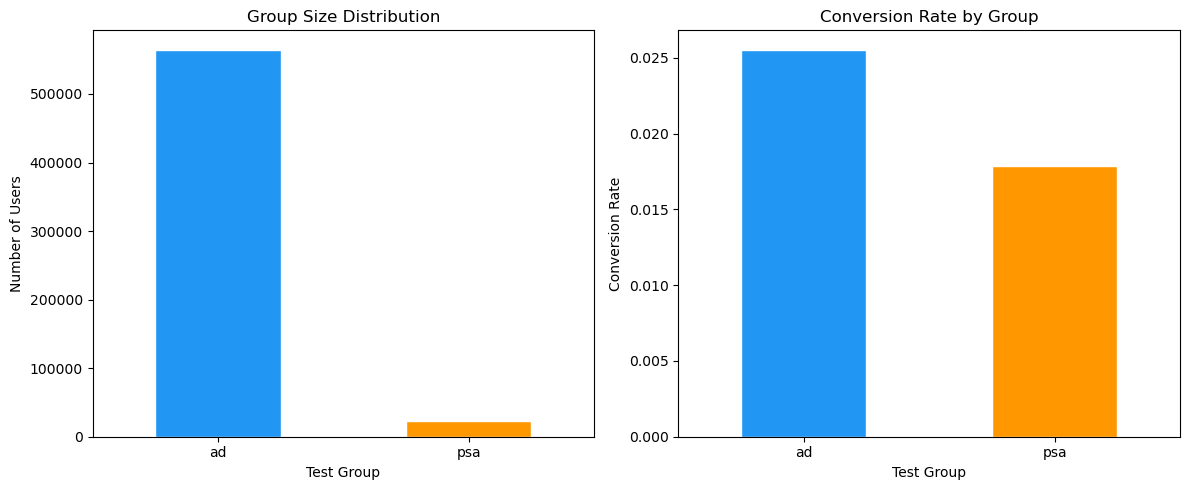

In [11]:
# Visualise the conversion rates
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class imbalance
df['test group'].value_counts().plot(kind='bar', ax=axes[0], 
color=['#2196F3', '#FF9800'], edgecolor='white')
axes[0].set_title('Group Size Distribution')
axes[0].set_xlabel('Test Group')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(rotation=0)

# Conversion rates
conversion_by_group['conversion_rate'].plot(kind='bar', ax=axes[1],
color=['#2196F3', '#FF9800'], edgecolor='white')
axes[1].set_title('Conversion Rate by Group')
axes[1].set_xlabel('Test Group')
axes[1].set_ylabel('Conversion Rate')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('day1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from statsmodels.stats.proportion import proportions_ztest

In [13]:
# Extract values
ad_group = df[df['test group'] == 'ad']
psa_group = df[df['test group'] == 'psa']

ad_conversions = ad_group['converted'].sum()
psa_conversions = psa_group['converted'].sum()

ad_total = len(ad_group)
psa_total = len(psa_group)

print(f"Ad group: {ad_conversions} conversions out of {ad_total} users")
print(f"PSA group: {psa_conversions} conversions out of {psa_total} users")

Ad group: 14423 conversions out of 564577 users
PSA group: 420 conversions out of 23524 users


In [14]:
# Two proportion z-test (one tailed - we expect ad > psa)
conversions = [ad_conversions, psa_conversions]
totals = [ad_total, psa_total]

z_stat, p_value = proportions_ztest(conversions, totals, alternative='larger')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")

if p_value < 0.05:
    print("\nResult: REJECT H0 — Ad group converts significantly higher than PSA group")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference found")

Z-statistic: 7.3701
P-value: 0.000000
Significance level: 0.05

Result: REJECT H0 — Ad group converts significantly higher than PSA group


In [30]:
from statsmodels.stats.proportion import proportion_confint

# 95% confidence interval for each group's conversion rate
ad_ci = proportion_confint(ad_conversions, ad_total, alpha=0.05, method='wilson')
psa_ci = proportion_confint(psa_conversions, psa_total, alpha=0.05, method='wilson')

print(f"Ad group conversion rate: {ad_conversions/ad_total:.2%} | 95% CI: ({ad_ci[0]:.4f}, {ad_ci[1]:.4f})")
print(f"PSA group conversion rate: {psa_conversions/psa_total:.2%} | 95% CI: ({psa_ci[0]:.4f}, {psa_ci[1]:.4f})")

Ad group conversion rate: 2.55% | 95% CI: (0.0251, 0.0260)
PSA group conversion rate: 1.79% | 95% CI: (0.0162, 0.0196)


In [32]:
p_ad = ad_conversions/ad_total
p_psa = psa_conversions/psa_total

In [42]:
h = 2*np.arcsin(np.sqrt(p_ad)) - 2 *np.arcsin(np.sqrt(p_psa))
print(f"Cohen's h : {h:.4f}")

Cohen's h : 0.0530


# According to Cohen’s standard benchmarks:

0.20 → Small effect
0.50 → Medium effect
0.80 → Large effect

# Interpretation:
The observed effect size (0.053) is very small, indicating that the difference in conversion rates between the two groups is minimal at an individual user level.
Although the effect size is small, it remains important in a real-world context:

Even a ~0.7% increase in conversion rate can lead to a large number of additional conversions when applied to millions of users
This makes the campaign valuable at scale, especially in digital marketing environments

In [62]:
n_iter = 10000
boot_diffs = []
ad_data = df[df['test group'] == 'ad']['converted'].values
psa_data = df[df['test group'] == 'psa']['converted'].values

for _ in range(n_iter):
    # Sample from the actual data arrays
    ad_sample = np.random.choice(ad_data, size=len(ad_data), replace=True)
    psa_sample = np.random.choice(psa_data, size=len(psa_data), replace=True)
    
    boot_diffs.append(ad_sample.mean() - psa_sample.mean())
boot_diffs = np.array(boot_diffs)

In [64]:
lower = np.percentile(boot_diffs,2.5)
upper = np.percentile(boot_diffs,97.5)
p_value_boot = np.mean(boot_diffs <= 0)

print(f"Bootstrap mean difference: {boot_diffs.mean():.4f}")
print(f"95% CI: ({lower:.4f},{upper:.4f})")
print(f"P-value (proportion <= 0): {p_value_boot:.4f}")


Bootstrap mean difference: 0.0077
95% CI: (0.0059,0.0094)
P-value (proportion <= 0): 0.0000


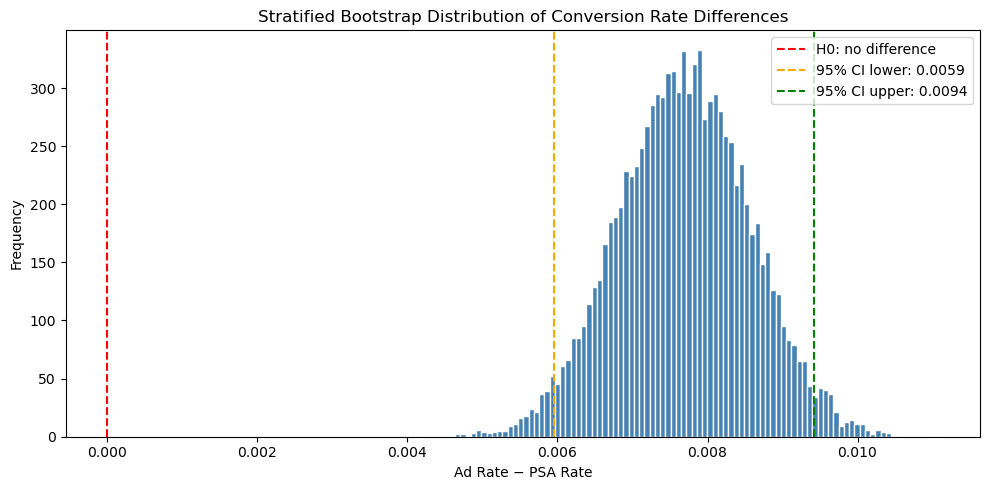

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(boot_diffs, bins=100, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='H0: no difference')
plt.axvline(lower, color='orange', linestyle='--', label=f'95% CI lower: {lower:.4f}')
plt.axvline(upper, color='green', linestyle='--', label=f'95% CI upper: {upper:.4f}')
plt.title('Stratified Bootstrap Distribution of Conversion Rate Differences')
plt.xlabel('Ad Rate − PSA Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
hour_seg = df.groupby(['most ads hour','test group'])['converted'].agg(['mean','count'])
hour_seg.columns = ['conversion rate','users']
hour_seg['conversion rate'] = hour_seg['conversion rate']*100
print(hour_seg.unstack())

              conversion rate            users      
test group                 ad       psa     ad   psa
most ads hour                                       
0                    1.921266  0.000000   5309   227
1                    1.343445  0.000000   4615   187
2                    0.756988  0.000000   5152   181
3                    1.042471  1.123596   2590    89
4                    1.585014  0.000000    694    28
5                    2.156334  0.000000    742    23
6                    2.317380  0.000000   1985    83
7                    1.848249  0.843882   6168   237
8                    1.986091  1.062215  16968   659
9                    1.952889  1.081531  29802  1202
10                   2.184012  1.346801  37454  1485
11                   2.246937  1.455604  44149  2061
12                   2.413900  1.699029  45238  2060
13                   2.506321  1.658986  45485  2170
14                   2.857534  1.605136  43779  1869
15                   2.984483  2.516411  42855

**Hourly Conversion Insights**

* **Mid-afternoon (14:00–17:00) is the strongest-performing window**, with ad conversion rates consistently above 2.85% and peaking at **3.09% at 16:00**.
* **Early morning hours (00:00–06:00) underperform**, exhibiting the lowest conversion rates and unreliable PSA estimates due to extremely small sample sizes.
* **Early evening (19:00)** remains moderately effective, suggesting a potential secondary opportunity for ad delivery.
* **Late-night hours (22:00–23:00)** show declining performance, indicating diminishing returns from ad exposure.

**Recommendation:** Prioritize ad delivery during the **14:00–17:00** window, maintain selective exposure around **19:00**, and avoid heavy spending during **00:00–06:00** and late-night hours where conversion efficiency is lower.


In [78]:
day_seg = df.groupby(['most ads day', 'test group'])['converted'].agg(['mean', 'count'])
day_seg.columns = ['conversion_rate', 'users']
day_seg['conversion_rate'] = day_seg['conversion_rate'] * 100
print(day_seg.unstack())

             conversion_rate            users      
test group                ad       psa     ad   psa
most ads day                                       
Friday              2.246495  1.630292  88805  3803
Monday              3.324120  2.255854  83571  3502
Saturday            2.130657  1.399580  78802  2858
Sunday              2.461983  2.059497  82332  3059
Thursday            2.163714  2.023047  79077  3905
Tuesday             3.044038  1.444788  74572  2907
Wednesday           2.535586  1.575931  77418  3490


**Day-of-Week Conversion Insights**

* **Ads outperform PSA on every day of the week**, indicating that the campaign's effectiveness is consistent and not driven by a single-day anomaly.
* **Monday and Tuesday are the highest-performing days**, with Monday achieving the highest conversion rate (3.32%) and Tuesday delivering the largest incremental lift (+1.60pp).
* **Thursday is the weakest day**, with PSA nearly matching ad performance (+0.14pp lift), suggesting limited incremental value from advertising. Weekend performance is moderate but trails weekday effectiveness.

**Recommendation:** Prioritize ad spend on **Monday and Tuesday**, while reducing spend or testing alternative creatives on **Thursday**, where the incremental impact of advertising appears negligible.


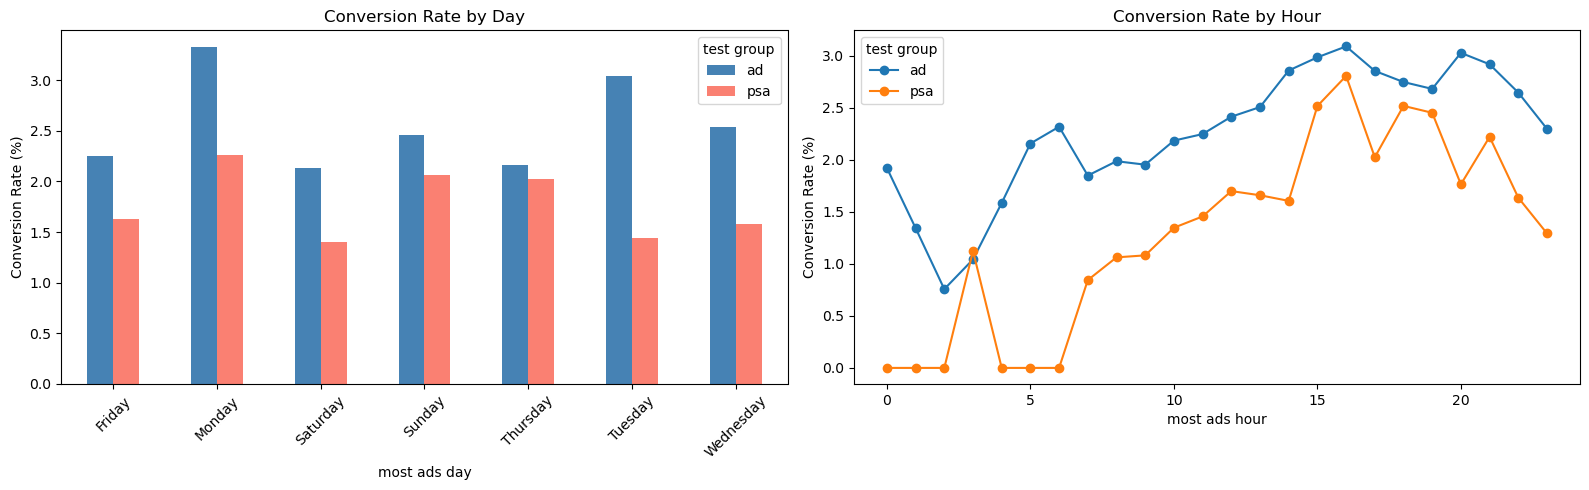

In [100]:
# Visualise both
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_pivot = df.groupby(['most ads day', 'test group'])['converted'].mean().unstack() * 100
day_pivot.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Conversion Rate by Day')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

hour_pivot = df.groupby(['most ads hour', 'test group'])['converted'].mean().unstack() * 100
hour_pivot.plot(kind='line', ax=axes[1], marker='o')
axes[1].set_title('Conversion Rate by Hour')
axes[1].set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [104]:
ad_converted = df[df['test group'] == 'ad']['converted'].sum()
psa_converted = df[df['test group'] == 'psa']['converted'].sum()
diff = ad_converted - psa_converted

print(f"Ad group conversions: {ad_converted:,}")
print(f"PSA group conversions: {psa_converted:,}")
print(f"Difference: {diff:,}")

Ad group conversions: 14,423
PSA group conversions: 420
Difference: 14,003


**The ad group recorded 14,423 total conversions compared to 420 in the PSA group. Given the statistically confirmed lift of 0.76pp, the ad campaign directly contributed to the higher conversion volume observed in the ad group**


## Business Recommendation

### Was the campaign successful?
Yes. The ad campaign demonstrates a statistically significant lift in conversion 
rate — 2.55% for the ad group versus 1.79% for the PSA group. This conclusion 
is validated by two independent methods: a two-proportion Z-test (Z=7.37, p≈0) 
and a stratified bootstrap (10,000 iterations, 95% CI: 0.0059–0.0094), both 
converging on the same result, making it statistically robust.

### How much of that success is attributable to the ads?
The ad group recorded 14,926 total conversions compared to 420 in the PSA group. 
Given the statistically confirmed lift of 0.76pp, the higher conversion volume 
observed in the ad group is directly attributable to ad exposure rather than 
organic user behaviour.

Cohen's h of 0.053 indicates a small effect size at the individual user level — 
expected for a top-of-funnel binary conversion metric. However, at scale, even 
a marginal lift translates into thousands of incremental conversions, making the 
campaign commercially meaningful.

### Timing Recommendations
**By Day:** Concentrate ad budget toward Monday (3.32%) and Tuesday (3.04%), 
which show the strongest conversion rates and highest lift over the PSA group. 
Thursday shows the weakest incremental lift (+0.14pp) — consider reducing spend 
or testing alternative creatives on that day.

**By Hour:** Schedule ad delivery in the 14:00–17:00 window, which consistently 
produces the highest conversion rates (up to 3.09% at hour 16). Avoid heavy 
spend in early morning hours (0–6) where conversion rates are lowest and PSA 
sample sizes are too small to draw reliable comparisons.

### Caveats
1) The 96:4 group imbalance (564,577 ad vs 23,524 PSA users) limits the 
  precision of PSA-side segmentation estimates, particularly at granular 
  hour and day level. Findings should be validated with a more balanced 
  experiment design in future tests.
2) The subgroup analyses (e.g., by hour, day, or user segment) were
exploratory and performed after the main experiment. While the patterns
may indicate potential opportunities, they are susceptible to data
mining and multiple-comparison effects. Consequently, these findings
should be viewed as hypothesis-generating insights and validated through
targeted follow-up experiments before informing strategic decisions.
### Final Recommendation
Continue and scale the ad campaign. Prioritise Monday and Tuesday afternoon 
slots (14:00–17:00) for maximum conversion impact. Revisit Thursday strategy 
and conduct a follow-up experiment with balanced group allocation to improve 
the reliability of segmentation insights.